In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

In [5]:
df = pd.read_csv("mtsamples.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (4999, 6)


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [6]:
print(df.info())
print("Missing Values:")
print(df.isnull().sum())
print("Columns:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB
None
Missing Values:
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64
Columns:
['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


In [7]:
df = df[['medical_specialty', 'transcription']]

display(df.head())

,medical_specialty,transcription
0,Allergy / Immunology,"SUBJECTIVE:, This 23-year-old white female pr..."
1,Bariatrics,"PAST MEDICAL HISTORY:, He has difficulty climb..."
2,Bariatrics,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,Cardiovascular / Pulmonary,"2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,Cardiovascular / Pulmonary,1. The left ventricular cavity size and wall ...


In [8]:
df = df.dropna(subset=['transcription'])

df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

print("Shape after removing missing transcriptions:", df.shape)

Shape after removing missing transcriptions: (4966, 2)


In [9]:
def remove_phi(text):
    text = str(text)

    # Email addresses
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
                  '[EMAIL]', text)

    # Phone numbers
    text = re.sub(r'\b(?:\+?\d{1,3}[-.\s]?)?(?:\(?\d{3}\)?[-.\s]?)\d{3}[-.\s]?\d{4}\b',
                  '[PHONE]', text)

    # Dates
    text = re.sub(r'\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b',
                  '[DATE]', text)

    # Years
    text = re.sub(r'\b(19|20)\d{2}\b',
                  '[YEAR]', text)

    return text

df['clean_text'] = df['transcription'].apply(remove_phi)

display(df[['transcription', 'clean_text']].head())

,transcription,clean_text
0,"SUBJECTIVE:, This 23-year-old white female pr...","SUBJECTIVE:, This 23-year-old white female pr..."
1,"PAST MEDICAL HISTORY:, He has difficulty climb...","PAST MEDICAL HISTORY:, He has difficulty climb..."
2,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","HISTORY OF PRESENT ILLNESS: , I have seen ABC ..."
3,"2-D M-MODE: , ,1. Left atrial enlargement wit...","2-D M-MODE: , ,1. Left atrial enlargement wit..."
4,1. The left ventricular cavity size and wall ...,1. The left ventricular cavity size and wall ...


In [10]:
def clean_text(text):
    text = str(text).lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_text'] = df['clean_text'].apply(clean_text)

display(df[['medical_specialty', 'clean_text']].head())

,medical_specialty,clean_text
0,Allergy / Immunology,subjective this 23 year old white female prese...
1,Bariatrics,past medical history he has difficulty climbin...
2,Bariatrics,history of present illness i have seen abc tod...
3,Cardiovascular / Pulmonary,2 d m mode 1 left atrial enlargement with left...
4,Cardiovascular / Pulmonary,1 the left ventricular cavity size and wall th...


In [11]:
print("Number of specialties:",
      df['medical_specialty'].nunique())

print("\nTop specialties:")
print(df['medical_specialty'].value_counts().head(10))

Number of specialties: 40

Top specialties:
medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Name: count, dtype: int64


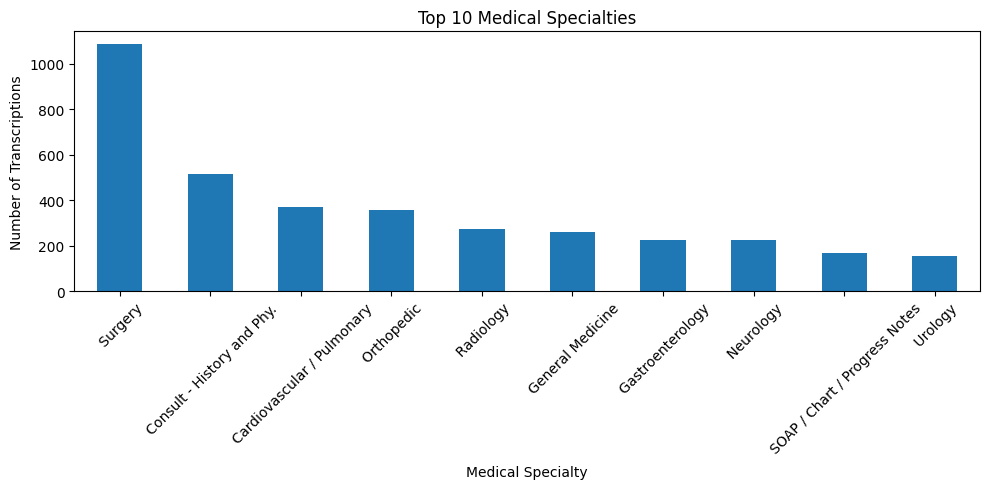

In [12]:
top_specialties = df['medical_specialty'].value_counts().head(10)

plt.figure(figsize=(10, 5))
top_specialties.plot(kind='bar')
plt.title("Top 10 Medical Specialties")
plt.xlabel("Medical Specialty")
plt.ylabel("Number of Transcriptions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

count    4966.000000
mean      486.492348
std       326.804548
min         1.000000
25%       256.000000
50%       420.000000
75%       644.000000
max      3112.000000
Name: word_count, dtype: float64


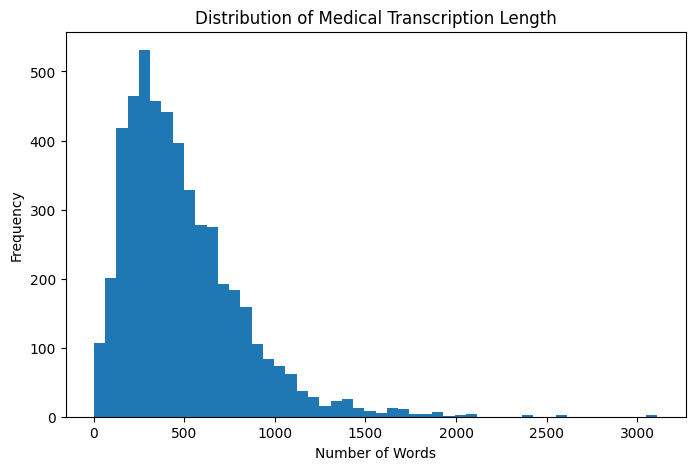

In [13]:
df['word_count'] = df['clean_text'].apply(
    lambda x: len(x.split())
)

print(df['word_count'].describe())
plt.figure(figsize=(8, 5))
plt.hist(df['word_count'], bins=50)
plt.title("Distribution of Medical Transcription Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [14]:
words = " ".join(df['clean_text']).split()

word_counts = Counter(words)

print("Most common words:")
print(word_counts.most_common(20))

Most common words:
[('the', 149888), ('and', 82779), ('was', 71765), ('of', 59205), ('to', 50632), ('a', 43031), ('with', 35815), ('in', 32808), ('is', 26378), ('patient', 24208), ('no', 17874), ('she', 17593), ('for', 17049), ('he', 15544), ('were', 15535), ('on', 14694), ('this', 13949), ('at', 13492), ('then', 12430), ('right', 11587)]


In [15]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = vectorizer.fit_transform(df['clean_text'])

print("TF-IDF shape:", X.shape)

TF-IDF shape: (4966, 5000)


In [16]:
encoder = LabelEncoder()

y = encoder.fit_transform(df['medical_specialty'])

print("Number of classes:", len(encoder.classes_))
print("Classes:")
print(encoder.classes_)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Number of classes: 40
Classes:
[' Allergy / Immunology' ' Autopsy' ' Bariatrics'
 ' Cardiovascular / Pulmonary' ' Chiropractic'
 ' Consult - History and Phy.' ' Cosmetic / Plastic Surgery' ' Dentistry'
 ' Dermatology' ' Diets and Nutritions' ' Discharge Summary'
 ' ENT - Otolaryngology' ' Emergency Room Reports' ' Endocrinology'
 ' Gastroenterology' ' General Medicine' ' Hematology - Oncology'
 ' Hospice - Palliative Care' ' IME-QME-Work Comp etc.'
 ' Lab Medicine - Pathology' ' Letters' ' Nephrology' ' Neurology'
 ' Neurosurgery' ' Obstetrics / Gynecology' ' Office Notes'
 ' Ophthalmology' ' Orthopedic' ' Pain Management'
 ' Pediatrics - Neonatal' ' Physical Medicine - Rehab' ' Podiatry'
 ' Psychiatry / Psychology' ' Radiology' ' Rheumatology'
 ' SOAP / Chart / Progress Notes' ' Sleep Medicine' ' Speech - Language'
 ' Surgery' ' Urology']
Training samples: 3972
Testing samples: 994


In [17]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3972, 5000)
X_test shape: (994, 5000)
y_train shape: (3972,)
y_test shape: (994,)
